In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import joblib


In [5]:
df = pd.read_csv("stayfinder_india_dataset.csv")
print("Dataset Shape:", df.shape)
df.head()
df.head()


Dataset Shape: (3000, 13)


,location,guests,bedrooms,beds,bathrooms,wifi,parking,kitchen,pool,gym,fireplace,security,price_per_night
0,Bhopal,8,3,5,3,1,0,1,1,1,0,0,13940
1,Dehradun,6,5,1,1,0,1,1,1,0,1,1,11246
2,Indore,8,1,6,2,0,1,0,1,1,1,0,12293
3,Udaipur,6,2,4,2,0,1,1,0,1,1,0,8814
4,Chennai,7,2,2,2,1,1,1,0,1,1,1,12259


In [6]:
le_location = LabelEncoder()

df["location"] = le_location.fit_transform(df["location"])

# If property_type exists in your dataset
if "property_type" in df.columns:
    le_property = LabelEncoder()
    df["property_type"] = le_property.fit_transform(df["property_type"])


In [7]:
X = df.drop("price_per_night", axis=1)
y = df["price_per_night"]

print("Features shape:", X.shape)


Features shape: (3000, 12)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [15]:
# Remove extreme price outliers (top & bottom 1%)
lower = df["price_per_night"].quantile(0.01)
upper = df["price_per_night"].quantile(0.99)

df = df[(df["price_per_night"] >= lower) & (df["price_per_night"] <= upper)]

print("New shape after outlier removal:", df.shape)


New shape after outlier removal: (2940, 13)


In [16]:
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


,n_estimators,500
,criterion,'squared_error'
,max_depth,25
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


,loss,'squared_error'
,learning_rate,0.05
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [18]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("R2 Score:", round(r2, 4))


MAE: 603.61
R2 Score: 0.876


In [11]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df


,Feature,Importance
1,guests,0.204929
8,pool,0.194491
0,location,0.145843
2,bedrooms,0.144927
4,bathrooms,0.084988
3,beds,0.068345
9,gym,0.047852
10,fireplace,0.033782
11,security,0.021453
6,parking,0.018399


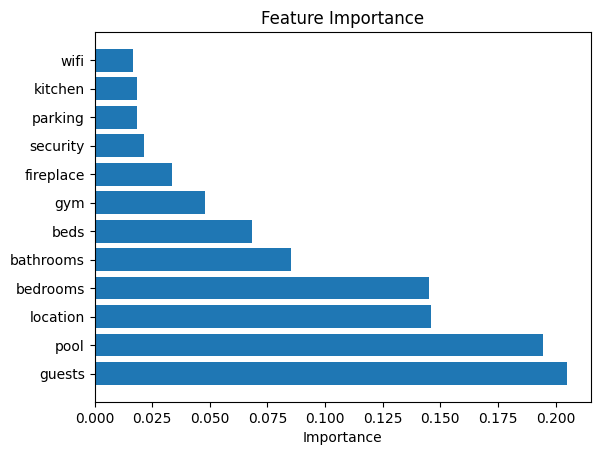

In [12]:
plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()


In [13]:
joblib.dump(model, "price_model.pkl")
joblib.dump(le_location, "location_encoder.pkl")

if "property_type" in df.columns:
    joblib.dump(le_property, "property_encoder.pkl")

print("Model saved successfully ✅")


Model saved successfully ✅


In [14]:
sample_data = X_test.iloc[[0]]  # take one real example
prediction = model.predict(sample_data)

print("Actual Price:", int(y_test.iloc[0]))
print("Predicted Price:", int(prediction[0]))


Actual Price: 7724
Predicted Price: 7724


In [19]:
import joblib

joblib.dump(model, "price_model.pkl")
joblib.dump(le_location, "location_encoder.pkl")


['location_encoder.pkl']